# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df = pd.read_csv("data_banknote_authentication.csv")
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [3]:
# Dataset shape and columns
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Shape: (1372, 5)

Columns: ['Variance_Wavelet', 'Skewness_Wavelet', 'Curtosis_Wavelet', 'Image_Entropy', 'Class']


In [4]:
# Basic statistics
df.describe()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Variance_Wavelet    0
Skewness_Wavelet    0
Curtosis_Wavelet    0
Image_Entropy       0
Class               0
dtype: int64


In [6]:
# Class distribution
print("Class distribution:")
print(df['Class'].value_counts())
print(f"\nClass balance: {df['Class'].value_counts(normalize=True).round(3).to_dict()}")


Class distribution:
Class
0    762
1    610
Name: count, dtype: int64

Class balance: {0: 0.555, 1: 0.445}


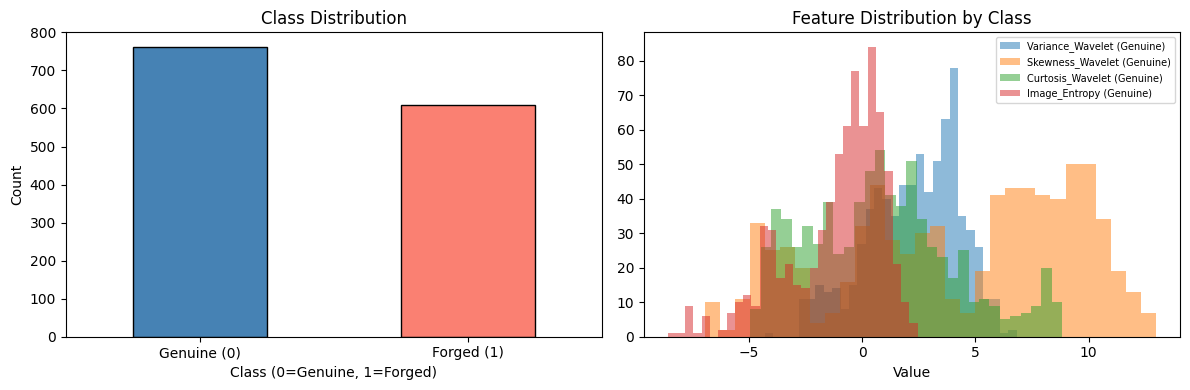

In [7]:
# Visualize dataset: class counts and feature distributions by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class count
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class (0=Genuine, 1=Forged)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Genuine (0)', 'Forged (1)'], rotation=0)

# Feature distributions
for col in df.columns[:-1]:
    axes[1].hist(df[df['Class']==0][col], alpha=0.5, label=f'{col} (Genuine)', bins=30)
axes[1].set_title('Feature Distribution by Class')
axes[1].set_xlabel('Value')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [9]:
# Split dataset into features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

Features shape: (1372, 4)
Target shape:   (1372,)


In [10]:
# Split dataset into training and testing sets (70% train, 30% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 960
Testing  samples : 412


# **Decision Tree**

In [11]:
# Train and evaluate a baseline Decision Tree classifier
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

print(f"Baseline Decision Tree Accuracy: {dt_base.score(X_test, y_test):.4f}")

Baseline Decision Tree Accuracy: 0.9879


In [12]:
# Perform hyperparameter tuning for Decision Tree using GridSearchCV
dt_param_grid = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator  = DecisionTreeClassifier(random_state=42),
    param_grid = dt_param_grid,
    cv         = 5,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)

dt_grid.fit(X_train, y_train)

print(f"\nBest Parameters : {dt_grid.best_params_}")
print(f"Best CV Score   : {dt_grid.best_score_:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Parameters : {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV Score   : 0.9906


In [13]:
# Best Decision Tree model
best_dt = dt_grid.best_estimator_
print(f"Test Accuracy (Tuned DT): {best_dt.score(X_test, y_test):.4f}")

Test Accuracy (Tuned DT): 0.9927


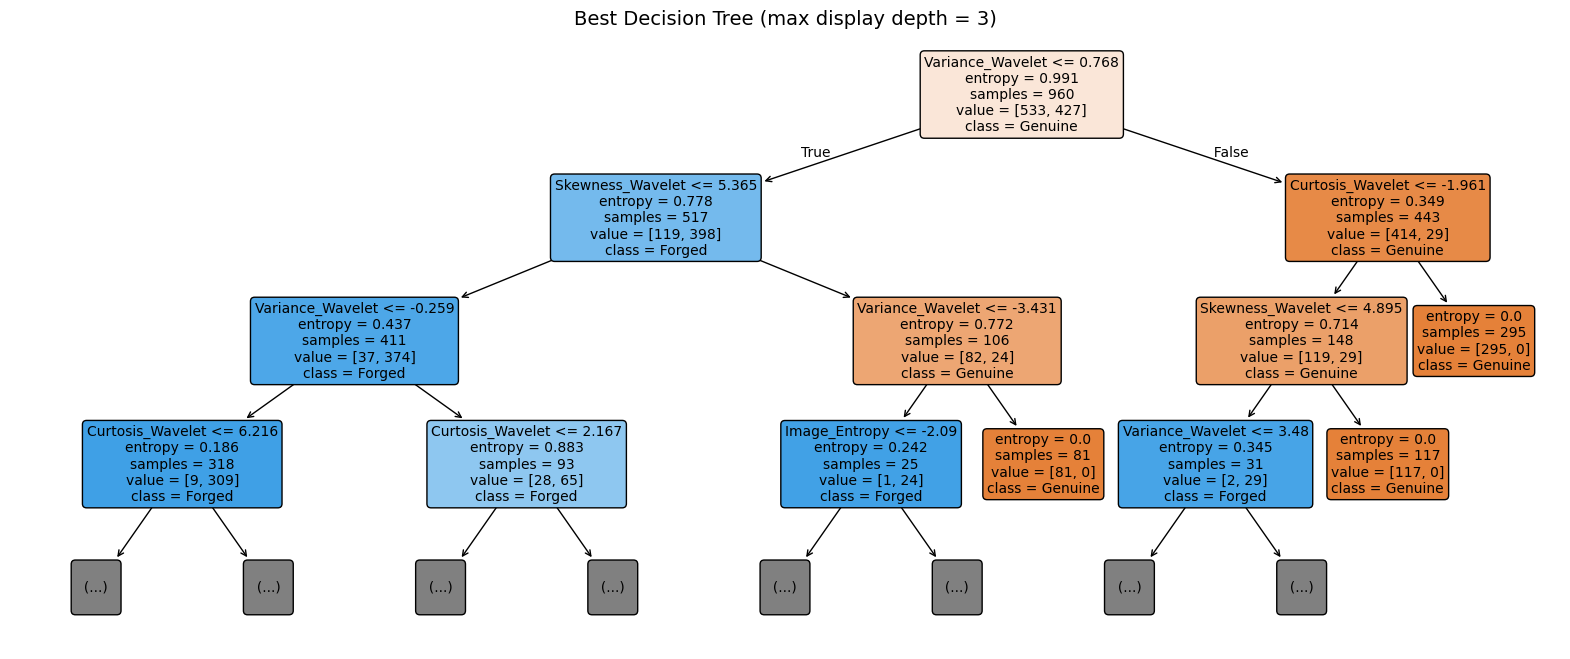

In [14]:
# Visualize the best Decision Tree (limited depth for readability)
plt.figure(figsize=(20, 8))
plot_tree(best_dt, feature_names=X.columns, class_names=['Genuine','Forged'],
          filled=True, rounded=True, max_depth=3, fontsize=10)
plt.title('Best Decision Tree (max display depth = 3)', fontsize=14)
plt.show()

# **Random Forest**

In [15]:
# --- Baseline Random Forest ---
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)

print(f"Baseline Random Forest Accuracy: {rf_base.score(X_test, y_test):.4f}")

Baseline Random Forest Accuracy: 0.9951


In [18]:
# Perform hyperparameter tuning for Random Forest using GridSearchCV
rf_param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [5, 10, 20, None],
    'max_features'     : ['sqrt', 'log2'],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

rf_grid = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = rf_param_grid,
    cv         = 5,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)

rf_grid.fit(X_train, y_train)

print(f"\nBest Parameters : {rf_grid.best_params_}")
print(f"Best CV Score   : {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best Parameters : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score   : 0.9927


In [19]:
# Best Random Forest model
best_rf = rf_grid.best_estimator_
print(f"Test Accuracy (Tuned RF): {best_rf.score(X_test, y_test):.4f}")

Test Accuracy (Tuned RF): 0.9951


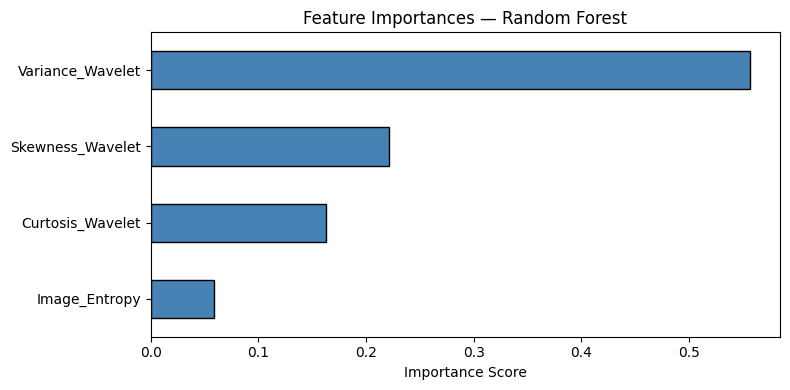

In [20]:
# Feature Importance from Random Forest
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# **Model Evaluation**

In [21]:
# Predictions from both models
y_pred_dt = best_dt.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

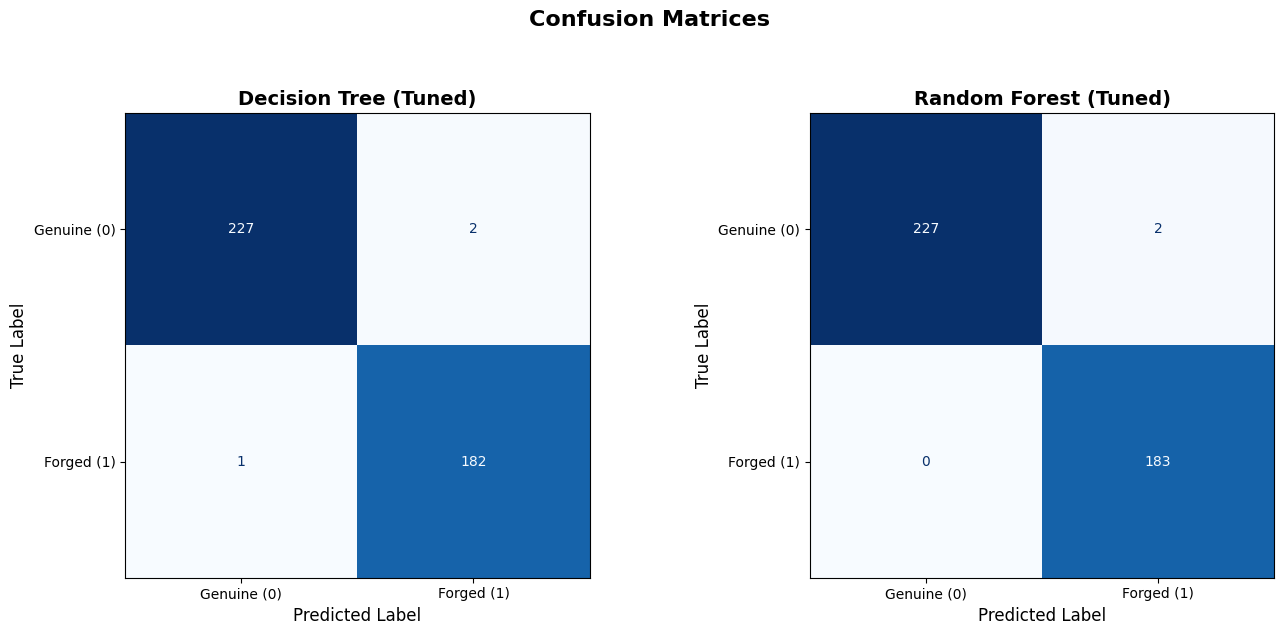

In [26]:
# Visualize confusion matrices for tuned Decision Tree and Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = [best_dt, best_rf]
preds  = [y_pred_dt, y_pred_rf]
titles = ['Decision Tree (Tuned)', 'Random Forest (Tuned)']

for ax, model, pred, title in zip(axes, models, preds, titles):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Genuine (0)', 'Forged (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    # Customize axes
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.tick_params(axis='both', labelsize=10)

plt.suptitle('Confusion Matrices', fontsize=16, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [28]:
# Display classification reports for tuned Decision Tree and Random Forest
models = {
    "DECISION TREE (Tuned)": y_pred_dt,
    "RANDOM FOREST (Tuned)" : y_pred_rf
}

for name, preds in models.items():
    print("\n" + "=" * 60)
    print(f"    {name} — Classification Report")
    print("=" * 60)
    print(classification_report(
        y_test,
        preds,
        target_names=['Genuine (0)', 'Forged (1)'],
        digits=4  # show metrics with 4 decimal places
    ))


    DECISION TREE (Tuned) — Classification Report
              precision    recall  f1-score   support

 Genuine (0)     0.9956    0.9913    0.9934       229
  Forged (1)     0.9891    0.9945    0.9918       183

    accuracy                         0.9927       412
   macro avg     0.9924    0.9929    0.9926       412
weighted avg     0.9927    0.9927    0.9927       412


    RANDOM FOREST (Tuned) — Classification Report
              precision    recall  f1-score   support

 Genuine (0)     1.0000    0.9913    0.9956       229
  Forged (1)     0.9892    1.0000    0.9946       183

    accuracy                         0.9951       412
   macro avg     0.9946    0.9956    0.9951       412
weighted avg     0.9952    0.9951    0.9951       412



# **Model Comparison & Discussion**

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to compute key classification metrics
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model'    : model_name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall'   : recall_score(y_true, y_pred),
        'F1-Score' : f1_score(y_true, y_pred),
    }

# Compile metrics for each model into a tidy DataFrame
results = pd.DataFrame([
    get_metrics(y_test, y_pred_dt, 'Decision Tree (Tuned)'),
    get_metrics(y_test, y_pred_rf, 'Random Forest (Tuned)')
]).set_index('Model').round(4)

# Display results with a nice header
print("\nClassification Metrics Comparison:\n")
display(results.style.background_gradient(cmap='Blues'))


Classification Metrics Comparison:



,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree (Tuned),0.992700,0.989100,0.994500,0.991800
Random Forest (Tuned),0.995100,0.989200,1.000000,0.994600


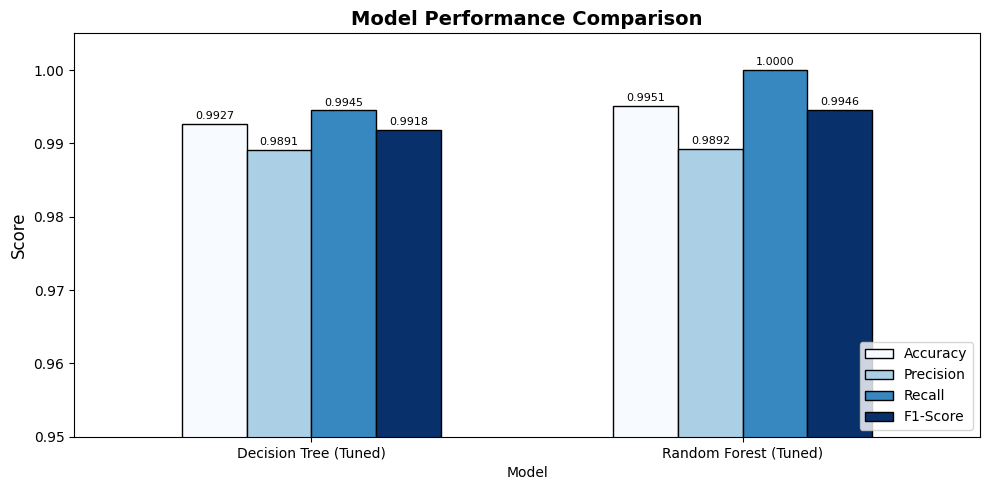

In [34]:
# Bar chart to compare Accuracy, Precision, Recall, and F1-Score of models
ax = results.plot(
    kind='bar',
    figsize=(10, 5),
    edgecolor='black',
    width=0.6,
    colormap='Blues'  # nicer color gradient
)

# Customize axes and title
ax.set_title('Model Performance Comparison', fontsize=14, weight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.95, 1.005)  # focus on high-performance range
ax.set_xticklabels(results.index, rotation=0, fontsize=10)
ax.legend(loc='lower right', fontsize=10)

# Add data labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

Random Forest generally outperforms a single Decision Tree because it reduces variance by aggregating the predictions of multiple trees.

The dataset is well-separated: the wavelet features particularly Variance_Wavelet and Skewness_Wavelet provide strong discriminating power, enabling even a single Decision Tree to achieve good performance.

Using GridSearchCV was crucial to prevent overfitting in the Decision Tree. Without controlling the tree depth and other hyperparameters, a Decision Tree can easily memorize the training data.

For deployment, Random Forest is preferred due to its robustness and higher generalization capability. However, for interpretability, the tuned Decision Tree remains more transparent and easier to understand.

Conclusion: For this banknote authentication task, Random Forest is the better model overall, offering superior generalization and a lower risk of overfitting compared to a single Decision Tree.